In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import os
import pandas as pd
import numpy as np
os.chdir('../../../results/PlantCAD2_tasks/')

In [2]:
species = ['eutrema_salsugineum', 'oryza_sativa', 'brachypodium_distachyon']
ckpts = ['pcv2-l24-d0768-checkpoints-lr-1e-4']
context = ['c300', 'c600', 'c1000']

In [3]:
pred_dict = {}
for s in species:
    pred_dict[s] = {}
    for ctx in context:
        ckpt = ckpts[0]
        path = f'accessible_angiosperm_{ctx}/{ckpt}/test_{s}_scores.tsv'
        pred_dict[s][ctx] = path

Average Precision Scores for eutrema_salsugineum:
  c300: 0.3359
  c600: 0.5246
  c1000: 0.6434
Average Precision Scores for oryza_sativa:
  c300: 0.2638
  c600: 0.5113
  c1000: 0.6194
Average Precision Scores for brachypodium_distachyon:
  c300: 0.0893
  c600: 0.2761
  c1000: 0.4365


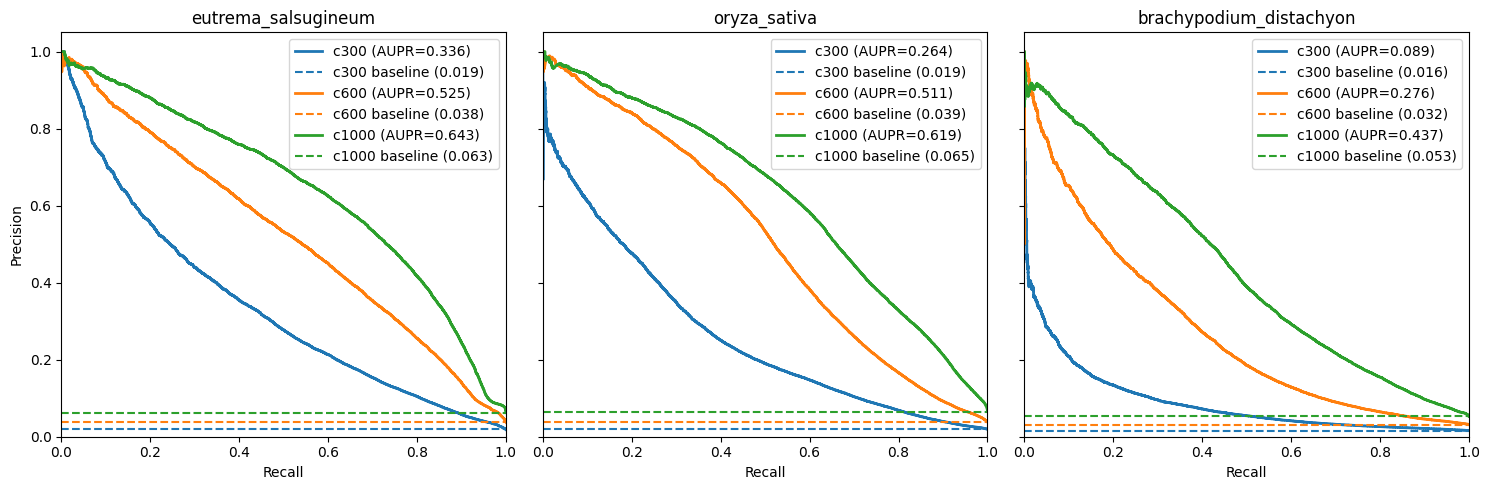

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Process each species
for i, sp in enumerate(species):
    curPATH = pred_dict[sp]
    
    ax = axes[i]
    
    ap_scores = {}
    color_idx = 0
    
    for ctx in curPATH.keys():
        predictions = pd.read_csv(curPATH[ctx], sep='\t')
        labels = pd.read_csv(f'accessible_angiosperm_{ctx}/test_{sp}.tsv.gz', sep='\t')
        
        y_scores = predictions['probability_positive']
        y_true = labels['Label']
        
        precision, recall, _ = precision_recall_curve(y_true, y_scores)
        
        ap = average_precision_score(y_true, y_scores)
        ap_scores[ctx] = ap
        
        baseline = np.mean(y_true)
        
        current_color = f'C{color_idx}'
        ax.plot(recall, precision, lw=2, color=current_color, label=f'{ctx} (AUPR={ap:.3f})')
        
        ax.plot([0, 1], [baseline, baseline], lw=1.5, color=current_color, linestyle='--', 
                label=f'{ctx} baseline ({baseline:.3f})')
        
        color_idx += 1
    
    ax.set_title(f'{sp}')
    ax.set_xlabel('Recall')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.legend(loc='upper right')
    
    print(f"Average Precision Scores for {sp}:")
    for ctx, score in ap_scores.items():
        print(f"  {ctx}: {score:.4f}")

axes[0].set_ylabel('Precision')

plt.tight_layout()

# Save the figure
plt.savefig('../../pipelines/lu_2019_ATACseq/figures/pr_curves_all_species.pdf', format='pdf', bbox_inches='tight')
plt.show()

## For non-genic only

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Process each species
for i, sp in enumerate(species):
    curPATH = pred_dict[sp]
    
    ax = axes[i]
    
    ap_scores = {}
    color_idx = 0
    
    for ctx in curPATH.keys():
        predictions = pd.read_csv(curPATH[ctx], sep='\t')
        labels = pd.read_csv(f'accessible_angiosperm_{ctx}/test_{sp}.tsv.gz', sep='\t')
        labels = pd.concat((labels, predictions), axis = 1)
        # remove genic regions
        labels = labels[labels['Type'] != 'genic']
        
        y_scores = labels['probability_positive']
        y_true = labels['Label']
        
        precision, recall, _ = precision_recall_curve(y_true, y_scores)
        
        ap = average_precision_score(y_true, y_scores)
        ap_scores[ctx] = ap
        
        baseline = np.mean(y_true)
        
        current_color = f'C{color_idx}'
        ax.plot(recall, precision, lw=2, color=current_color, label=f'{ctx} (AUPR={ap:.3f})')
        
        ax.plot([0, 1], [baseline, baseline], lw=1.5, color=current_color, linestyle='--', 
                label=f'{ctx} baseline ({baseline:.3f})')
        
        color_idx += 1
    
    ax.set_title(f'{sp}')
    ax.set_xlabel('Recall')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.legend(loc='upper right')
    
    print(f"Average Precision Scores for {sp}:")
    for ctx, score in ap_scores.items():
        print(f"  {ctx}: {score:.4f}")

axes[0].set_ylabel('Precision')

plt.tight_layout()

# Save the figure
plt.savefig('../../pipelines/lu_2019_ATACseq/figures/pr_curves_all_species_non_genic.pdf', format='pdf', bbox_inches='tight')
plt.show()